<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_1/blob/main/05_%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 선형회귀

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [125]:
# 라이브러리 임포트

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
from torchviz import make_dot

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [126]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [127]:
# device 설정 코드
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

5.3 선형회귀

In [128]:
l = nn.Linear(2, 3)
print(l)
# w1x1 + w2x2 + b

Linear(in_features=2, out_features=3, bias=True)


In [129]:
# 난수 시드값 고정 (항상 동일한 결과를 얻기 위함)
torch.manual_seed(123)

# 입력: 1, 출력: 1 선형 함수를 정의합니다.
# y = w1x1 + b
l1 = nn.Linear(1,1)

# 생성된 선형 함수를 확인합니다.
print(l1)

Linear(in_features=1, out_features=1, bias=True)


In [130]:
print("\nl1의 파라미터:")
for param in l1.named_parameters():
    print('name  :', param[0])       # 파라미터 이름 출력
    print('tensor:', param[1])       # 파라미터 텐서 값 출력
    print('shape :', param[1].shape) # 파라미터 텐서의 모양 출력


l1의 파라미터:
name  : weight
tensor: Parameter containing:
tensor([[-0.4078]], requires_grad=True)
shape : torch.Size([1, 1])
name  : bias
tensor: Parameter containing:
tensor([0.0331], requires_grad=True)
shape : torch.Size([1])


In [131]:
# 초깃값 설정 (weight=2.0, bias=1.0)
nn.init.constant_(l1.weight, 2.0)
nn.init.constant_(l1.bias, 1.0)

# 결과 확인
print(l1.weight)
print(l1.bias)

Parameter containing:
tensor([[2.]], requires_grad=True)
Parameter containing:
tensor([1.], requires_grad=True)


In [132]:
# 테스트용 데이터 생성

# -2부터 2까지 1씩 증가하는 NumPy 배열 생성
x_np = np.arange(-2.0, 2.1, 1.0)
print(x_np)

# NumPy 배열을 PyTorch 텐서로 변환
x = torch.tensor(x_np).float() # .float()으로 데이터 타입을 float32로 지정
print(x)
print("x의 shape:", x.shape)
print("x의 값:\n", x)


# (N, 1) 사이즈로 변경. N은 데이터 개수.
# 선형 함수는 기본적으로 배치(묶음) 데이터를 처리하므로 2차원 텐서 입력을 가정합니다.
x = x.view(-1, 1)  # [5,1]
print(x)

# 결과 확인
print("x의 shape:", x.shape)
print("x의 값:\n", x)


[-2. -1.  0.  1.  2.]
tensor([-2., -1.,  0.,  1.,  2.])
x의 shape: torch.Size([5])
x의 값:
 tensor([-2., -1.,  0.,  1.,  2.])
tensor([[-2.],
        [-1.],
        [ 0.],
        [ 1.],
        [ 2.]])
x의 shape: torch.Size([5, 1])
x의 값:
 tensor([[-2.],
        [-1.],
        [ 0.],
        [ 1.],
        [ 2.]])


In [133]:
# 함수테스트

y = l1(x)
print(y)
# 결과 확인
print("y의 shape:", y.shape)
print("y의 data:\n", y.data) # y.data는 requires_grad 정보 없이 순수 데이터만 보여줍니다.

tensor([[-3.],
        [-1.],
        [ 1.],
        [ 3.],
        [ 5.]], grad_fn=<AddmmBackward0>)
y의 shape: torch.Size([5, 1])
y의 data:
 tensor([[-3.],
        [-1.],
        [ 1.],
        [ 3.],
        [ 5.]])


In [134]:
# 입력: 2, 출력: 1 선형 함수 정의
l2 = nn.Linear(2, 1)

# 초깃값 설정 (모든 가중치는 1.0, 편향은 2.0으로 설정)
nn.init.constant_(l2.weight, 1.0)
nn.init.constant_(l2.bias, 2.0)

# y = w1x1 + w2x2 + b >> y = 1x1 + 1x2 + 2
# 결과 확인
print("weight:", l2.weight)
print("bias:", l2.bias)

weight: Parameter containing:
tensor([[1., 1.]], requires_grad=True)
bias: Parameter containing:
tensor([2.], requires_grad=True)


In [135]:
x2_np = np.array([[0, 0],[0, 1],[1,0],[1,1]])
x2 = torch.tensor(x2_np).float()

# 결과확인
print(x2.shape)
print(x2)

torch.Size([4, 2])
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])


In [136]:
# 함수 값 계산
y2 = l2(x2)
print(y2.shape)
print(y2.data)

torch.Size([4, 1])
tensor([[2.],
        [3.],
        [3.],
        [4.]])


In [137]:
# 입력 : 2, 출력 : 3, 선형 함수 정의
l3 = nn.Linear(2,3)

# 가독성 위해 [0,:] 표기
# nn.init.constant_(l3.weight[0,:], 1.0)
# nn.init.constant_(l3.weight[1,:], 2.0)
# nn.init.constant_(l3.weight[2,:], 3.0)
# nn.init.constant_(l3.bias, 2.0)

nn.init.constant_(l3.weight[0], 1.0)
nn.init.constant_(l3.weight[1], 2.0)
nn.init.constant_(l3.weight[2], 3.0)
nn.init.constant_(l3.bias, 2.0)

# 결과 확인
print(l3.weight)
print(l3.bias)

Parameter containing:
tensor([[1., 1.],
        [2., 2.],
        [3., 3.]], requires_grad=True)
Parameter containing:
tensor([2., 2., 2.], requires_grad=True)


In [138]:
# 함수 값 계산
y3 = l3(x2)

print(y3.shape)
print(y3.data)

torch.Size([4, 3])
tensor([[2., 2., 2.],
        [3., 4., 5.],
        [3., 4., 5.],
        [4., 6., 8.]])


5.4 커스텀 클래스를 이용한 모델 정의

In [139]:
# 모델 정의
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        # 부모 클래스 nn.Module
        super().__init__()

        # 출력층 정의
        self.l1 = nn.Linear(n_input, n_output)

    # 예측 함수 정의
    def forward(self, x):
        x1 = self.l1(x)
        return x1

In [140]:
# 더미 입력
inputs = torch.ones(100,1)

# 인스턴스 생성 (1 입력, 1 출력 선형 모델)
n_input = 1
n_output = 1
net = Net(n_input, n_output)

# 예측
outputs = net(inputs)

print(outputs.shape)
# 처음 5개 예측값 출력
print(outputs[:5])

torch.Size([100, 1])
tensor([[-0.5637],
        [-0.5637],
        [-0.5637],
        [-0.5637],
        [-0.5637]], grad_fn=<SliceBackward0>)


5.5 MSELoss 클래스를 이용한 손실 함수

In [141]:
labels1 = torch.zeros(100, 1) # 정답이 모두 0이라고 가정

# 손실함수 : 평균 제곱 오차 (Mean Square Error)
criterion = nn.MSELoss()

In [142]:
# 손실 계산
loss = criterion(outputs, labels1)

# 경사 계산
loss.backward()

5.6 데이터 준비

In [143]:
# 학습용 데이터셋 준비

# '보스턴 데이터셋'은 현재 사이킷런 라이브러리에서 가져올 수 있지만,
# 사이킷런에서 앞으로 이 데이터를 사용할 수 없기 때문에 웹 url에서 직접 수집

data_url = "http://lib.stat.cmu.edu/datasets/boston"
# 원본 데이터
raw_df = pd.read_csv(data_url, sep="\s+",
                     skiprows=22, header=None)
# print(raw_df)
x_org = np.hstack([raw_df.values[::2, :],
                   raw_df.values[1::2, :2]])
# print(x_org)
yt = raw_df.values[1::2, 2]
# print(yt)
feature_names = np.array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX',
                          'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO','B', 'LSTAT'])

# 결과 확인
print('원본 데이터', x_org.shape, yt.shape)
print('항목명: ', feature_names)

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_41008/3197529071.py:8: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+",


원본 데이터 (506, 13) (506,)
항목명:  ['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']


In [144]:
# 데이터 추출 (RM 항목)
x = x_org[:, feature_names=='RM']
print('추출 후', x.shape)
print(x[:5,:])

# 정답 데이터 y 표시
print('정답 데이터')
print(yt[:5])

추출 후 (506, 1)
[[6.575]
 [6.421]
 [7.185]
 [6.998]
 [7.147]]
정답 데이터
[24.  21.6 34.7 33.4 36.2]


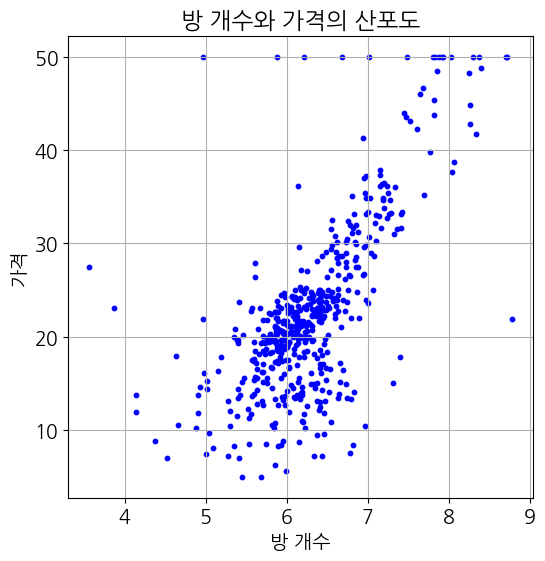

In [145]:
# 산포도 출력

plt.scatter(x, yt, s=10,c="b")
plt.xlabel('방 개수')
plt.ylabel('가격')
plt.title('방 개수와 가격의 산포도')
plt.show()

5.7 모델 정의

In [146]:
# 변수 정의

# 입력 차원 수
n_input = x.shape[1]

# 출력 차원수
n_output = 1

print(f'입력 차원수: {n_output} 출력 차원수: {n_output}')

입력 차원수: 1 출력 차원수: 1


In [147]:
# 머신러닝 모델(예측 모델)의 클래스 정의

class Net(nn.Module):
    def __init__(self, n_input, n_output):
        # 부모 클래스 호출
        super().__init__()

        # 출력층 정의
        self.l1 = nn.Linear(n_input, n_output)

        # 초기값 모두 1로 설
        nn.init.constant_(self.l1.weight, 1.0)
        nn.init.constant_(self.l1.bias, 1.0)

    # 예측 함수 정의
    def forward(self, x):
        x1 = self.l1(x)     # 선형 회귀
        return x1

꿀팁 : 에러 없이 CPU, GPU 둘 다 사용하는 방법

device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Model 정의 model = model.to(device)

input을 gpu도 호환되게 맞추어줌

inputs = inputs.to(device)

labels=labels.view(-1, feature).to(device)

[여기서 잠깐]

plt 또는 연산하게 될 경우 >> .cpu().numpy()

In [148]:
# 인스턴스 생성
# 1 입력, 1 출력 선형 모델
# 모델에 device 설정

net = Net(n_input, n_output).to(device)

In [149]:
# 모델 안의 파라미터를 확인
# 모델 안의 변수를 가져오기 위해 named_parameters() 함수를 사용
# 첫번째 요소는 변수명, 두번째 요소가 변수값

for parameter in net.named_parameters():
    print(f'변수명: {parameter[0]}')
    print(f'변수명: {parameter[1].data}')

변수명: l1.weight
변수명: tensor([[1.]])
변수명: l1.bias
변수명: tensor([1.])


In [150]:
# 파라미터 리스트 반환을 위해 parameters() 함수를 사용
for parameter in net.parameters():
    print(parameter)

Parameter containing:
tensor([[1.]], requires_grad=True)
Parameter containing:
tensor([1.], requires_grad=True)


In [151]:
# 모델의 개요 표시 1

print(net)

Net(
  (l1): Linear(in_features=1, out_features=1, bias=True)
)


In [152]:
# 모델의 개요 표시 2

from torchinfo import summary
summary(net, (1,))
# (1,) : 입력 텐서의 shape

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       2
Total params: 2
Trainable params: 2
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [153]:
# 손실 함수
criterion = nn.MSELoss()

# 학습률
lr = 0.001

# 최적화 함수 : 경사하강법
# net.parameters() : 파라미터 조정(파라미터: 학습대상, w,b)
optimizer = optim.SGD(net.parameters(), lr=lr)

5.8 경사하강법

In [154]:
# 입력값 x와 정답 yt의 텐서 변수화
inputs = torch.tensor(x).float()
labels = torch.tensor(yt).float()

# 차원 수 확인
print(inputs.shape)
print(labels.shape)

torch.Size([506, 1])
torch.Size([506])


In [155]:
# 손실 계산을 위해 labels를 (N,1) 차원의 행렬로 변환
labels1 = labels.view(-1,1)
print(labels1.shape)

torch.Size([506, 1])


In [156]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels1)
print(f'손실값: {loss:.5f}')

손실값: 308.44986


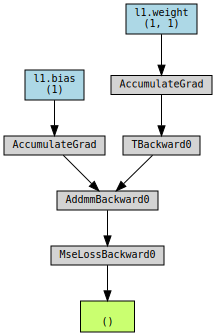

In [157]:
# 손실 그래프로 그리기
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [158]:
# 경사 계산
loss.backward()

# 경사 계산 결과
print(net.l1.weight.grad)
print(net.l1.bias.grad)

tensor([[-199.6421]])
tensor([-30.4963])


In [159]:
# 파라미터 수정
optimizer.step()

# 파라미터 확인
print(net.l1.weight)
print(net.l1.bias)

Parameter containing:
tensor([[1.1996]], requires_grad=True)
Parameter containing:
tensor([1.0305], requires_grad=True)


In [160]:
# 경사값 초기화
optimizer.zero_grad()

# 경사값 초기화 확인
print(net.l1.weight.grad)
print(net.l1.bias.grad)

None
None


In [161]:
# 전체 흐름 반복 계산

# 학습률
lr = 0.01

# 인스턴스 생성
net = Net(n_input, n_output).to(device)

# 손실 함수(평균 제곱 오차)
criterion = nn.MSELoss()

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 5000

# 평가 결과 기록 (손실 값만 기록)
history = np.zeros((0,2))

In [162]:
# 반복 계산 메인 루프
for epoch in range(num_epochs):
    # 경사값 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 손실 계산
    loss = criterion(outputs, labels1)

    # 역전파
    loss.backward()

    # 파라미터 재설정
    optimizer.step()

    # 100회 마다 경과를 기록
    if (epoch % 1000 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch {epoch} loss: {loss.item():.5f}')

Epoch 0 loss: 308.44986
Epoch 1000 loss: 53.50045
Epoch 2000 loss: 49.72031
Epoch 3000 loss: 47.38356
Epoch 4000 loss: 45.93908


5.9 결과 확인

In [163]:
history

array([[   0.    ,  308.4499],
       [1000.    ,   53.5005],
       [2000.    ,   49.7203],
       [3000.    ,   47.3836],
       [4000.    ,   45.9391]])

In [164]:
print(f'초기 손실값 : {history[0,1]:.5f}')
print(f'최종 손실값 : {history[4,1]:.5f}')

초기 손실값 : 308.44986
최종 손실값 : 45.93908


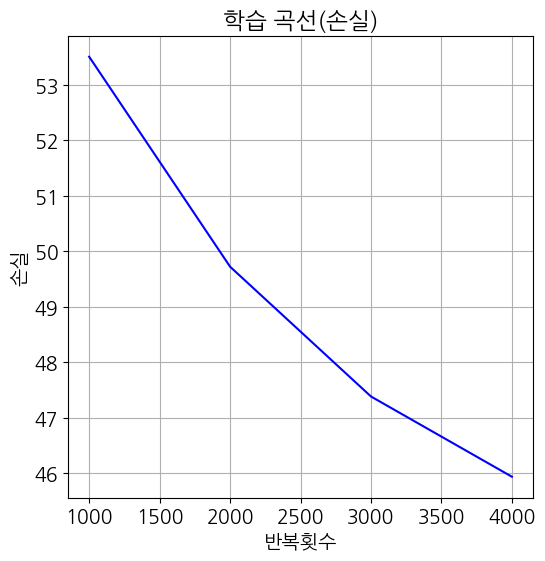

In [165]:
# 학습 곡선 출력(손실)

plt.plot(history[1:,0], history[1:,1], 'b')
plt.xlabel('반복횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

In [166]:
# 회귀 직선 산출

# x의 최솟값, 최댓값
xse = np.array((x.min(), x.max())).reshape(-1,1)
Xse = torch.tensor(xse).float().to(device)

with torch.no_grad():
  Yse = net(Xse)

print(Yse.cpu().numpy())

[[ 2.5101]
 [41.127 ]]


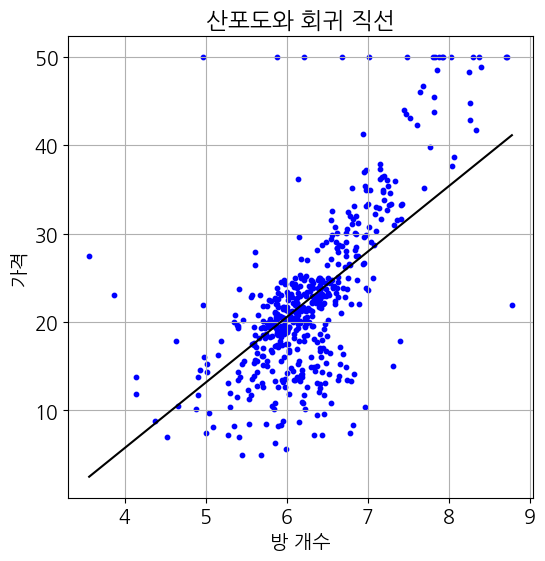

In [167]:
# 산포도와 회귀 직선 출력

plt.scatter(x, yt, s=10, c='b')
plt.xlabel('방 개수')
plt.ylabel('가격')
plt.plot(Xse, Yse, c='k')
plt.title('산포도와 회귀 직선')
plt.show()

5.10 중회귀 모델로 확장

In [168]:
# 코드 5-41 입력 변수 x2의 작성

# 열(LSTAT: 저소득자 비율) 추가
x_add = x_org[:, feature_names == 'LSTAT']
x2 = np.hstack((x, x_add))

# shape 표시
print(x2.shape)

# 입력 데이터 x2 표시
print(x2[:5,:])

(506, 2)
[[6.575 4.98 ]
 [6.421 9.14 ]
 [7.185 4.03 ]
 [6.998 2.94 ]
 [7.147 5.33 ]]


In [169]:
# 력 차원수를 2로 하는 모델 인스턴스 재생성
n_input = x2.shape[1]
print(n_input)

# 모델 인스턴스 생성
net = Net(n_input, n_output)

2


In [170]:
# 모델 안의 파라미터 확인
# predict.weight가 2차원으로 바뀜
for parameter in net.named_parameters():
    print(f'변수명: {parameter[0]}')
    print(f'변숫값: {parameter[1].data}')

변수명: l1.weight
변숫값: tensor([[1., 1.]])
변수명: l1.bias
변숫값: tensor([1.])


In [171]:
# 모델의 개요 1

print(net)

Net(
  (l1): Linear(in_features=2, out_features=1, bias=True)
)


In [172]:
# 모델의 개요 2
from torchinfo import summary
summary(net, (2,))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       3
Total params: 3
Trainable params: 3
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [173]:
# 입력 변수 x2를 텐서로 변환
# labels, labels1은 이전과 같음
inputs = torch.tensor(x2).float().to(device)

In [174]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [175]:
# 초기화 처리

# 학습률
lr = 0.01

# 인스턴스 생성(파라미터 값 초기화)
net = Net(n_input, n_output)

net = net.to(device)

# 손실 함수：평균 제곱 오차
criterion = nn.MSELoss().to(device)

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 5000

# 평가 결과 기록(손실 값만 기록)
history = np.zeros((0,2))

In [176]:
# 100회마다 도중 경과를 기록
for epoch in range(num_epochs):

    # 경삿값 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 오차 계산
    loss = criterion(outputs, labels1)

    # 경사 계산
    loss.backward()

    # 파라미터 수정
    optimizer.step()

    # 100회 마다 도중 경과를 기록
    if ( epoch % 100 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch {epoch} loss: {loss.item():.5f}')

Epoch 0 loss: 224.12796
Epoch 100 loss: nan
Epoch 200 loss: nan
Epoch 300 loss: nan
Epoch 400 loss: nan
Epoch 500 loss: nan
Epoch 600 loss: nan
Epoch 700 loss: nan
Epoch 800 loss: nan
Epoch 900 loss: nan
Epoch 1000 loss: nan
Epoch 1100 loss: nan
Epoch 1200 loss: nan
Epoch 1300 loss: nan
Epoch 1400 loss: nan
Epoch 1500 loss: nan
Epoch 1600 loss: nan
Epoch 1700 loss: nan
Epoch 1800 loss: nan
Epoch 1900 loss: nan
Epoch 2000 loss: nan
Epoch 2100 loss: nan
Epoch 2200 loss: nan
Epoch 2300 loss: nan
Epoch 2400 loss: nan
Epoch 2500 loss: nan
Epoch 2600 loss: nan
Epoch 2700 loss: nan
Epoch 2800 loss: nan
Epoch 2900 loss: nan
Epoch 3000 loss: nan
Epoch 3100 loss: nan
Epoch 3200 loss: nan
Epoch 3300 loss: nan
Epoch 3400 loss: nan
Epoch 3500 loss: nan
Epoch 3600 loss: nan
Epoch 3700 loss: nan
Epoch 3800 loss: nan
Epoch 3900 loss: nan
Epoch 4000 loss: nan
Epoch 4100 loss: nan
Epoch 4200 loss: nan
Epoch 4300 loss: nan
Epoch 4400 loss: nan
Epoch 4500 loss: nan
Epoch 4600 loss: nan
Epoch 4700 loss: na

5.11 학습률의 변경

In [177]:
# 초기화 처리

# 학습률
# lr = 0.01
lr = 0.001

# 인스턴스 생성
net = Net(n_input, n_output).to(device)

# 손실 함수(평균 제곱 오차)
criterion = nn.MSELoss()

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
# num_epochs = 5000
num_epochs = 2000

# 평가 결과 기록 (손실 값만 기록)
history = np.zeros((0,2))

In [178]:
for epoch in range(num_epochs):
    # 경사값 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 손실 계산
    loss = criterion(outputs, labels1)

    # 역전파
    loss.backward()

    # 파라미터 재설정
    optimizer.step()

    # 100회 마다 경과를 기록
    if (epoch % 1000 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch {epoch} loss: {loss.item():.5f}')

Epoch 0 loss: 224.12796
Epoch 1000 loss: 30.56040


In [179]:
history

array([[   0.    ,  224.128 ],
       [1000.    ,   30.5604]])

In [185]:
print(f'초기 손실값 : {history[0,1]:.5f}')
print(f'최종 손실값 : {history[-1,1]:.5f}')
# 학습률 변경 전보다 성능이 향상된 점 확인 가능
# 45.93908 >> 30.56040

초기 손실값 : 224.12796
최종 손실값 : 30.56040


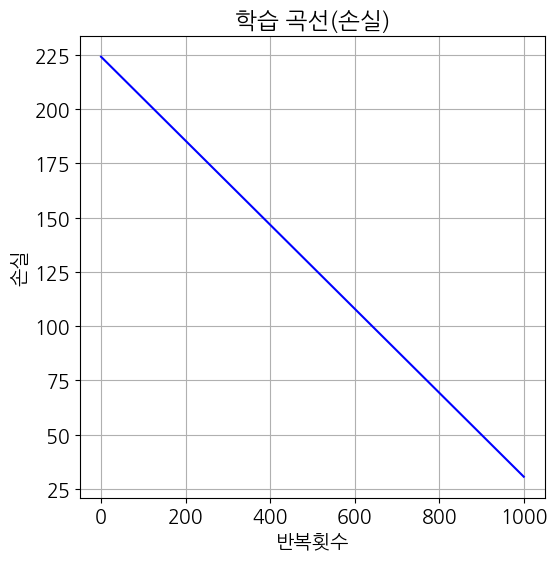

In [184]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b')
plt.xlabel('반복횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

In [181]:
# eos